# Air Quality Index (AQI) Prediction Project
This notebook implements a **complete end-to-end Data Science pipeline** on `final-dataset.csv` and trains a model to predict **AQI**.

## What this notebook covers (methods)
1. Problem definition (regression)
2. Data loading + data understanding
3. Data cleaning (missing values, duplicates, data types, outliers, sanity checks)
4. Exploratory Data Analysis (EDA) with plots
5. Feature engineering (time-based features + cyclical encoding)
6. Train/Test split using **time order** (time-series best practice)
7. Model comparison (baseline + multiple ML models)
8. Hyperparameter tuning (GridSearchCV with TimeSeriesSplit)
9. Final evaluation on unseen test set
10. Model saving (joblib) for deployment

> **Target (y):** `AQI`  
> **Key predictors (X):** PM2.5, Temp, Hum, Month/Day/Hour + engineered time features


In [4]:

# 1) Imports
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

sns.set_theme(style="whitegrid")


## 2) Load dataset

In [5]:

# NOTE: Put 'final-dataset.csv' in the same folder as this notebook.
# If you're running in a different environment, update the path below.
DATA_PATH = "final-dataset.csv"

df = pd.read_csv(DATA_PATH)
df.head()


,Time,Year,Month,Day,Hour,AQI,PM2.5,Temp,Hum
0,2024-03-02 16:00:00,2024,3,2,16,140,51,23,67
1,2024-03-02 17:00:00,2024,3,2,17,140,51,23,68
2,2024-03-02 18:00:00,2024,3,2,18,130,47,23,68
3,2024-03-02 19:00:00,2024,3,2,19,138,50,23,68
4,2024-03-02 20:00:00,2024,3,2,20,146,54,23,67


## 3) Data understanding

In [6]:

print("Shape (rows, cols):", df.shape)
print("\nColumns:", list(df.columns))
print("\nData types:\n", df.dtypes)

# Basic checks
print("\nMissing values per column:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Shape (rows, cols): (2604, 9)

Columns: ['Time', 'Year', 'Month', 'Day', 'Hour', 'AQI', 'PM2.5', 'Temp', 'Hum']

Data types:
 Time     object
Year      int64
Month     int64
Day       int64
Hour      int64
AQI       int64
PM2.5     int64
Temp      int64
Hum       int64
dtype: object

Missing values per column:
 Time     0
Year     0
Month    0
Day      0
Hour     0
AQI      0
PM2.5    0
Temp     0
Hum      0
dtype: int64

Duplicate rows: 0


## 4) Data cleaning

In [7]:

# Convert Time to datetime and sort
df["Time"] = pd.to_datetime(df["Time"], errors="coerce")
df = df.sort_values("Time").reset_index(drop=True)

# Drop rows where Time couldn't be parsed (if any)
before = len(df)
df = df.dropna(subset=["Time"]).reset_index(drop=True)
print("Dropped rows with invalid Time:", before - len(df))

# Optional: Remove unrealistic AQI=0 row (if it exists) - keeps model cleaner
zero_aqi = (df["AQI"] == 0).sum()
print("Rows with AQI == 0:", zero_aqi)
df = df[df["AQI"] > 0].reset_index(drop=True)

# Confirm hourly regularity (should be 1 hour)
diffs = df["Time"].diff().dropna()
non_hourly = (diffs != pd.Timedelta(hours=1)).sum()
print("Non-hourly gaps found:", non_hourly)

df.describe(include="all").T


Dropped rows with invalid Time: 0
Rows with AQI == 0: 1
Non-hourly gaps found: 1


,count,mean,min,25%,50%,75%,max,std
Time,2603,2024-04-25 21:00:55.320783872,2024-03-02 16:00:00,2024-03-29 18:30:00,2024-04-25 21:00:00,2024-05-22 23:30:00,2024-06-19 03:00:00,NaN
Year,2603.0,2024.0,2024.0,2024.0,2024.0,2024.0,2024.0,0.0
Month,2603.0,4.349597,3.0,3.0,4.0,5.0,6.0,1.050213
Day,2603.0,15.011525,1.0,8.0,14.0,22.0,31.0,8.589978
Hour,2603.0,11.509412,0.0,5.0,12.0,18.0,23.0,6.935481
AQI,2603.0,127.436035,7.0,93.0,120.0,158.0,381.0,46.960914
PM2.5,2603.0,60.138302,2.0,32.0,45.0,75.0,331.0,43.436677
Temp,2603.0,30.192086,15.0,26.0,30.0,36.0,43.0,6.296906
Hum,2603.0,45.580868,14.0,36.0,44.0,55.0,90.0,12.522995


### Outlier handling (IQR capping)
Because AQI/PM2.5 can have extreme spikes, we use **IQR capping** (winsorization) on selected predictors. We compute bounds on the training set and apply the same bounds on the test set (no data leakage).

In [8]:

def iqr_bounds(s):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    return lo, hi

# Quick outlier counts (before capping)
for col in ["AQI", "PM2.5", "Temp", "Hum"]:
    lo, hi = iqr_bounds(df[col])
    outliers = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f"{col:6} outliers: {outliers:4} | bounds=({lo:.1f}, {hi:.1f})")


AQI    outliers:   33 | bounds=(-4.5, 255.5)
PM2.5  outliers:  168 | bounds=(-32.5, 139.5)
Temp   outliers:    0 | bounds=(11.0, 51.0)
Hum    outliers:    3 | bounds=(7.5, 83.5)


## 5) Exploratory Data Analysis (EDA)

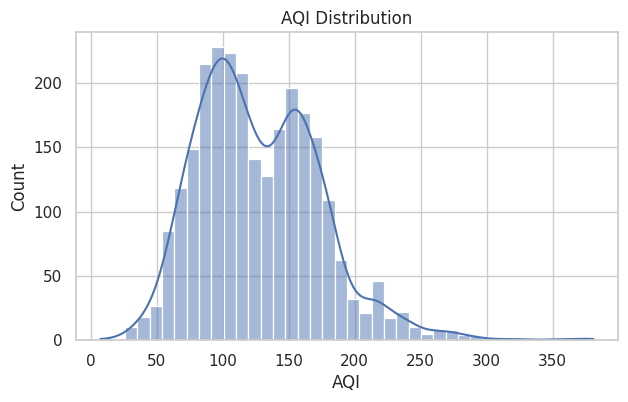

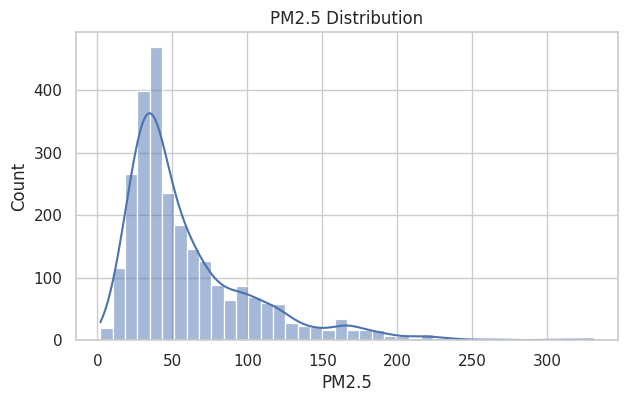

In [9]:

# Distribution plots
fig, ax = plt.subplots(figsize=(7,4))
sns.histplot(df["AQI"], bins=40, kde=True, ax=ax)
ax.set_title("AQI Distribution")
plt.show()

fig, ax = plt.subplots(figsize=(7,4))
sns.histplot(df["PM2.5"], bins=40, kde=True, ax=ax)
ax.set_title("PM2.5 Distribution")
plt.show()


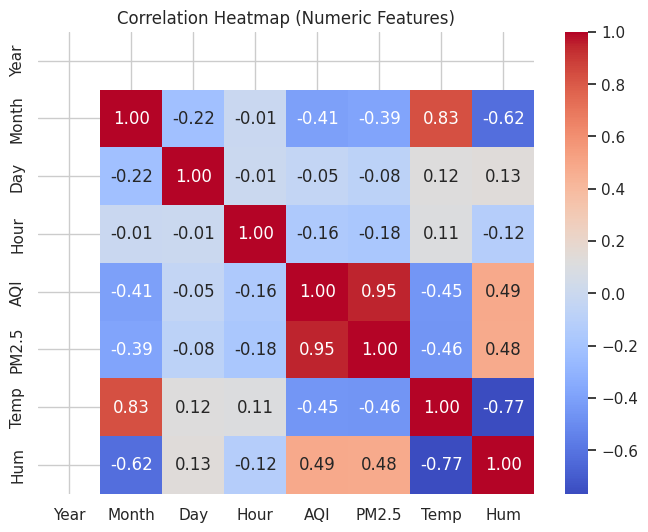


Correlation with AQI (descending):
AQI      1.000000
PM2.5    0.951174
Hum      0.488600
Day     -0.045372
Hour    -0.155794
Month   -0.406964
Temp    -0.452061
Year          NaN
Name: AQI, dtype: float64


In [10]:

# Correlation heatmap
corr = df.drop(columns=["Time"]).corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

print("\nCorrelation with AQI (descending):")
print(corr["AQI"].sort_values(ascending=False))


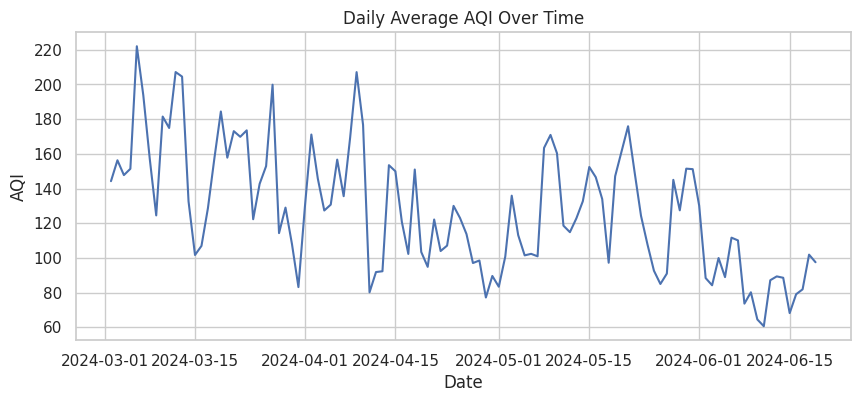

In [11]:

# AQI trend over time (daily mean)
daily = df.set_index("Time").resample("D")[["AQI","PM2.5","Temp","Hum"]].mean()

plt.figure(figsize=(10,4))
plt.plot(daily.index, daily["AQI"])
plt.title("Daily Average AQI Over Time")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.show()


## 6) Feature engineering
We create additional time-based features:
- DayOfWeek, DayOfYear
- Cyclical encodings for Hour and DayOfWeek (sin/cos)
This helps the model learn periodic patterns (day/night, weekly cycles).

In [12]:

df_feat = df.copy()

df_feat["DayOfWeek"] = df_feat["Time"].dt.dayofweek
df_feat["DayOfYear"] = df_feat["Time"].dt.dayofyear

# Cyclical encodings
df_feat["Hour_sin"] = np.sin(2*np.pi*df_feat["Hour"]/24)
df_feat["Hour_cos"] = np.cos(2*np.pi*df_feat["Hour"]/24)

df_feat["DOW_sin"] = np.sin(2*np.pi*df_feat["DayOfWeek"]/7)
df_feat["DOW_cos"] = np.cos(2*np.pi*df_feat["DayOfWeek"]/7)

# Define target and features
y = df_feat["AQI"]
X = df_feat.drop(columns=["AQI", "Time"])

# Drop Year if constant (often constant in small datasets)
if X["Year"].nunique() == 1:
    X = X.drop(columns=["Year"])

X.head()


,Month,Day,Hour,PM2.5,Temp,Hum,DayOfWeek,DayOfYear,Hour_sin,Hour_cos,DOW_sin,DOW_cos
0,3,2,16,51,23,67,5,62,-0.866025,-5.000000e-01,-0.974928,-0.222521
1,3,2,17,51,23,68,5,62,-0.965926,-2.588190e-01,-0.974928,-0.222521
2,3,2,18,47,23,68,5,62,-1.000000,-1.836970e-16,-0.974928,-0.222521
3,3,2,19,50,23,68,5,62,-0.965926,2.588190e-01,-0.974928,-0.222521
4,3,2,20,54,23,67,5,62,-0.866025,5.000000e-01,-0.974928,-0.222521


## 7) Train/Test split (chronological)
Because this is time-based (hourly) data, we split without shuffling:
- Train = first 80%
- Test = last 20%

In [13]:

split_idx = int(len(df_feat) * 0.80)

X_train = X.iloc[:split_idx].copy()
X_test  = X.iloc[split_idx:].copy()

y_train = y.iloc[:split_idx].copy()
y_test  = y.iloc[split_idx:].copy()

print("Train size:", X_train.shape, "| Test size:", X_test.shape)
print("Train time range:", df_feat["Time"].iloc[0], "to", df_feat["Time"].iloc[split_idx-1])
print("Test  time range:", df_feat["Time"].iloc[split_idx], "to", df_feat["Time"].iloc[-1])


Train size: (2082, 12) | Test size: (521, 12)
Train time range: 2024-03-02 16:00:00 to 2024-05-28 09:00:00
Test  time range: 2024-05-28 10:00:00 to 2024-06-19 03:00:00


### Apply IQR capping to selected predictors (no leakage)

In [14]:

def cap_iqr(train_s, s):
    lo, hi = iqr_bounds(train_s)
    return s.clip(lo, hi), lo, hi

cap_columns = ["PM2.5", "Hum"]  # capping the most spiky predictors

cap_bounds = {}
for col in cap_columns:
    X_train[col], lo, hi = cap_iqr(X_train[col], X_train[col])
    X_test[col] = X_test[col].clip(lo, hi)
    cap_bounds[col] = (lo, hi)

cap_bounds


{'PM2.5': (np.float64(-44.5), np.float64(167.5)),
 'Hum': (np.float64(9.5), np.float64(85.5))}

## 8) Model comparison
We compare multiple models:
- Baseline (Dummy mean)
- Ridge Regression (linear but stable)
- KNN Regression
- Random Forest
- Gradient Boosting

We use **TimeSeriesSplit cross-validation** on training data for fair comparison.

In [15]:

from sklearn.model_selection import TimeSeriesSplit, cross_validate

tscv = TimeSeriesSplit(n_splits=5)

def cv_scores(model, X_tr, y_tr, scaled=False):
    if scaled:
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", model)
        ])
    else:
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", model)
        ])

    scoring = {"rmse": "neg_root_mean_squared_error", "r2": "r2"}
    cv = cross_validate(pipe, X_tr, y_tr, cv=tscv, scoring=scoring)
    rmse = -cv["test_rmse"].mean()
    r2 = cv["test_r2"].mean()
    return rmse, r2

# Reduced feature set for linear/knn to avoid multicollinearity
cols_linear = ["PM2.5","Temp","Hum","Hour_sin","Hour_cos","DOW_sin","DOW_cos"]
X_train_lin = X_train[cols_linear]

models = [
    ("Baseline (Dummy mean)", DummyRegressor(strategy="mean"), X_train, False),
    ("Ridge (reduced features)", Ridge(random_state=42), X_train_lin, True),
    ("KNN (default)", KNeighborsRegressor(), X_train_lin, True),
    ("Random Forest", RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1), X_train, False),
    ("Gradient Boosting", GradientBoostingRegressor(random_state=42), X_train, False),
]

rows = []
for name, model, Xtr, scaled in models:
    rmse, r2 = cv_scores(model, Xtr, y_train, scaled=scaled)
    rows.append([name, rmse, r2])

comparison = pd.DataFrame(rows, columns=["Model", "CV_RMSE (lower better)", "CV_R2 (higher better)"]).sort_values("CV_RMSE (lower better)")
comparison


,Model,CV_RMSE (lower better),CV_R2 (higher better)
4,Gradient Boosting,10.355600,0.944763
3,Random Forest,10.447372,0.944046
1,Ridge (reduced features),16.577410,0.856849
2,KNN (default),31.364228,0.463445
0,Baseline (Dummy mean),48.522328,-0.289928


## 9) Hyperparameter tuning
We tune:
- **KNN** (k, distance weighting, p)
- **Gradient Boosting** (n_estimators, learning_rate, max_depth, subsample)

We use **GridSearchCV + TimeSeriesSplit** (no shuffling).

In [16]:

# --- KNN Tuning (reduced features + scaling) ---
X_test_lin = X_test[cols_linear]

knn_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", KNeighborsRegressor())
])

knn_params = {
    "model__n_neighbors": [3,5,7,9,11,15,21,31],
    "model__weights": ["uniform", "distance"],
    "model__p": [1,2]  # 1=Manhattan, 2=Euclidean
}

knn_grid = GridSearchCV(
    knn_pipe,
    knn_params,
    cv=TimeSeriesSplit(n_splits=4),
    scoring="neg_root_mean_squared_error",
    n_jobs=1
)

knn_grid.fit(X_train_lin, y_train)
print("Best KNN params:", knn_grid.best_params_)
print("Best KNN CV RMSE:", -knn_grid.best_score_)


Best KNN params: {'model__n_neighbors': 31, 'model__p': 1, 'model__weights': 'distance'}
Best KNN CV RMSE: 30.428122248026956


In [17]:

# --- Gradient Boosting Tuning (full feature set) ---
gb_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingRegressor(random_state=42))
])

gb_params = {
    "model__n_estimators": [200, 300],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3],
    "model__subsample": [0.8, 1.0]
}

gb_grid = GridSearchCV(
    gb_pipe,
    gb_params,
    cv=TimeSeriesSplit(n_splits=3),
    scoring="neg_root_mean_squared_error",
    n_jobs=1
)

gb_grid.fit(X_train, y_train)
print("Best GB params:", gb_grid.best_params_)
print("Best GB CV RMSE:", -gb_grid.best_score_)


Best GB params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}
Best GB CV RMSE: 10.620447985073035


## 10) Final evaluation on test set
We evaluate tuned models on the **unseen last 20% test data** using:
- MAE
- RMSE
- R²

Then we choose the best model and save it.

In [19]:
def eval_on_test(name, fitted_model, X_te, y_te):
    pred = fitted_model.predict(X_te)
    mae = mean_absolute_error(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    r2 = r2_score(y_te, pred)
    return name, mae, rmse, r2, pred

best_knn = knn_grid.best_estimator_
best_gb  = gb_grid.best_estimator_

rows = []
name, mae, rmse, r2, pred_knn = eval_on_test("Tuned KNN", best_knn, X_test_lin, y_test)
rows.append([name, mae, rmse, r2])

name, mae, rmse, r2, pred_gb = eval_on_test("Tuned Gradient Boosting", best_gb, X_test, y_test)
rows.append([name, mae, rmse, r2])

test_results = pd.DataFrame(rows, columns=["Model","MAE","RMSE","R2"]).sort_values("RMSE")
test_results

,Model,MAE,RMSE,R2
1,Tuned Gradient Boosting,4.185632,4.981990,0.974841
0,Tuned KNN,23.984789,28.315048,0.187305


Best model on test: Tuned Gradient Boosting


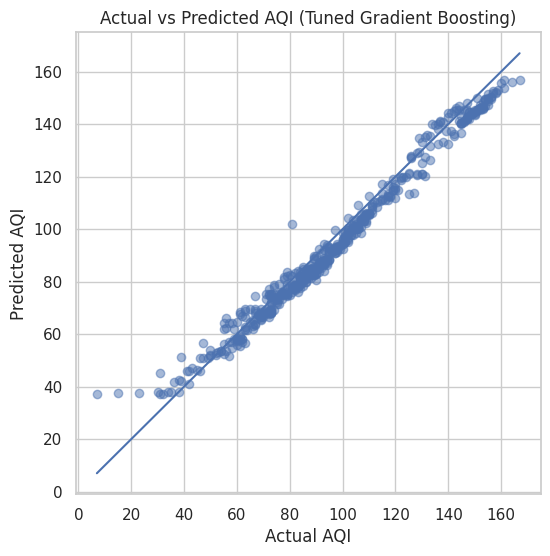

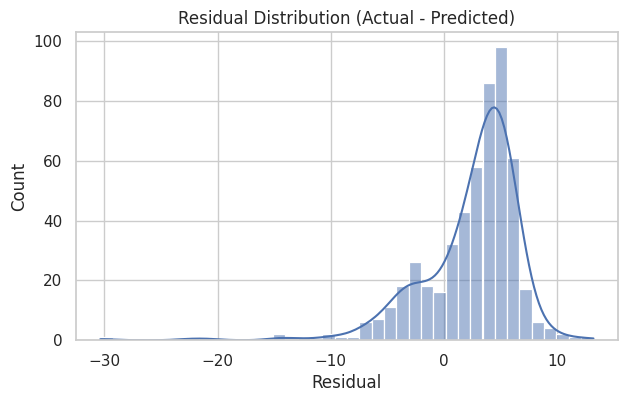

In [20]:

# Plot: Actual vs Predicted (best model assumed to be the top row by RMSE)
best_model_name = test_results.iloc[0]["Model"]
print("Best model on test:", best_model_name)

if best_model_name == "Tuned Gradient Boosting":
    y_pred = pred_gb
else:
    y_pred = pred_knn

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title(f"Actual vs Predicted AQI ({best_model_name})")
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.show()

# Residuals
residuals = y_test - y_pred
plt.figure(figsize=(7,4))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Residual Distribution (Actual - Predicted)")
plt.xlabel("Residual")
plt.show()


## 11) Save the final model
We save the **entire pipeline** (preprocessing + model) so it can be loaded and used for prediction later.

In [21]:

FINAL_MODEL_PATH = "aqi_best_pipeline.pkl"

# Choose best fitted model
final_model = best_gb if best_model_name == "Tuned Gradient Boosting" else best_knn

joblib.dump(final_model, FINAL_MODEL_PATH)
print("Saved:", FINAL_MODEL_PATH)


Saved: aqi_best_pipeline.pkl


## 12) How to use the saved model (example)
This shows how to load and predict for new rows (same feature columns).

In [23]:

loaded = joblib.load(FINAL_MODEL_PATH)

# Example: take the last 3 test rows and predict
sample_X = X_test.head(3) if best_model_name == "Tuned Gradient Boosting" else X_test_lin.head(3)

print("Input values for prediction (first 3 samples from test set):")
display(sample_X)

pred = loaded.predict(sample_X)

# Create a DataFrame to display inputs and predictions together
predictions_df = sample_X.copy()
predictions_df['Predicted_AQI'] = pred

print("\nInput values with Predicted AQI:")
display(predictions_df)


Input values for prediction (first 3 samples from test set):


,Month,Day,Hour,PM2.5,Temp,Hum,DayOfWeek,DayOfYear,Hour_sin,Hour_cos,DOW_sin,DOW_cos
2082,5,28,10,61,36,37,1,149,5.000000e-01,-0.866025,0.781831,0.62349
2083,5,28,11,61,36,37,1,149,2.588190e-01,-0.965926,0.781831,0.62349
2084,5,28,12,60,36,36,1,149,1.224647e-16,-1.000000,0.781831,0.62349



Input values with Predicted AQI:


,Month,Day,Hour,PM2.5,Temp,Hum,DayOfWeek,DayOfYear,Hour_sin,Hour_cos,DOW_sin,DOW_cos,Predicted_AQI
2082,5,28,10,61,36,37,1,149,5.000000e-01,-0.866025,0.781831,0.62349,145.207732
2083,5,28,11,61,36,37,1,149,2.588190e-01,-0.965926,0.781831,0.62349,145.207732
2084,5,28,12,60,36,36,1,149,1.224647e-16,-1.000000,0.781831,0.62349,145.247621
